# jetfighter-rl  Project overview

**Teaching a simulated F-16 to fly with reinforcement learning.**

This repository is the learning half of a two-repository project. The aircraft  (3-DOF and
6-DOF flight dynamics with NASA wind-tunnel tables, instruments, fly-by-wire and autopilot)
comes from [**jetfighter-sim**](https://github.com/elouansalaun/jetfighter-sim), installed as the `jetsim` package. This repository
adds what turns it into a learning problem:

* **phase 7** : a Gymnasium environment (`JetEnv`) with tasks, observations, shaped rewards and
  reference policies;
* **phase 8** : a curriculum of maneuvers learned with PPO: stabilize, reach a heading and
  altitude, sustained turn, 3D waypoints, aerobatics ; first through the fly-by-wire, then by
  moving the control surfaces directly.

| # | Notebook | What it shows |
|---|---|---|
| 0 | [`00_project_overview`](00_project_overview.ipynb) | Goal, architecture, decisions, results at a glance |
| 1–6 | [jetfighter-sim](https://github.com/elouansalaun/jetfighter-sim/tree/main/notebooks) | Physics, 3-DOF / 6-DOF models, instruments, visualization, classical control |
| 7 | [`07_gym_environment`](07_gym_environment.ipynb) | Turning the simulator into a Gymnasium RL environment |
| 8 | [`08_rl_maneuvers`](08_rl_maneuvers.ipynb) | Training PPO agents: curriculum, reward hacking, imitation, results |

## 1. The goal


1. a trustworthy flight simulator (phases 1–5) : [jetfighter-sim](https://github.com/elouansalaun/jetfighter-sim);
2. a classical autopilot as a reference (phase 6) : [jetfighter-sim](https://github.com/elouansalaun/jetfighter-sim);
3. a reinforcement-learning environment (phase 7) : **this repository**;
4. a curriculum of maneuvers learned by RL , stabilize, turn, navigate, loop (phase 8) :
   **this repository**;
5. then a missile model and evasion training (phases 9–10, not started yet).


## 2. Architecture

```
                  ┌──────────────────────────────────────────────────┐
                  │  RL agent (PPO, SAC, imitation)   phase 8        │
jetfighter-rl     │  Gymnasium env: tasks, rewards    phase 7        │  ◄ this repo
                  └─────────┬────────────────────────────▲───────────┘
                    command │                            │ observation,
                            │                            │ reward, done
                  ┌─────────▼────────────────────────────┴───────────┐
                  │  control/   fly-by-wire, autopilot  phase 6      │
jetsim            │  aircraft/  3-DOF & 6-DOF dynamics  phases 2-3   │
                  │             instruments, sensors,                │
                  │             flight envelope         phase 4      │
                  │  core/      frames, ISA, RK4        phase 1      │
                  │  viz/       recording, Tacview      phase 5      │
                  └──────────────────────────────────────────────────┘
```

The agent can act at two levels:

* **hierarchical** : it commands load factor, roll rate and throttle, and the fly-by-wire of
  `jetsim` moves the surfaces; far easier to learn, used for 8.1–8.5;
* **low level** : it moves the elevator, ailerons, rudder and throttle directly at 50 Hz,
  with nothing to protect it from stalling or overstressing the airframe (step 8.6).

Two aircraft models share the same interfaces, so every task runs on either the fast 3-DOF
point mass or the realistic 6-DOF rigid body.

## 3. Key design decisions

The roadmap (`project_roadmap.md`) keeps a decision log. The entries that shaped the learning:

| Decision | Why |
|---|---|
| **Hierarchical agent first, direct surface control later** | Commanding load factor and roll rate is far easier to learn than raw elevator/aileron; it validates the whole RL pipeline before the hard version |
| **Crash penalty = fixed + worst cost of all remaining steps** | Otherwise, far from the target, crashing was *cheaper* than continuing to fly |
| **Zero action = hold the current flight path** | With "zero = 1 g", the policy had to output 1/cos(bank) to two decimals just to not descend in a turn |
| **Gravity direction instead of Euler angles in the observation** | Euler angles flip by 180° when passing the vertical; a looping agent "thought it was inverted" and stopped |
| **Normalized rewards, 1 torch thread, reduced initial exploration** | Critic explained variance ≈ 0 without normalization; 6× throughput with one thread; σ = 1 random commands crash in seconds |
| **Imitation of the reference as a warm start** for 8.2 and 8.5 | Pure RL on 8.2 over 3 runs: 90 %, 60 %, 20 % success; for aerobatics it only discovered the roll |

Several of these were discovered *by watching trajectories*, not by looking at reward curves
; a recurring theme in notebook 8.

## 4. Conventions

Consistency is enforced across the whole code base, in both repositories:

| Topic | Convention |
|---|---|
| Units | **SI everywhere** internally; conversions only at the boundaries |
| Angles | **Radians** internally; degrees only for display and config files |
| Inertial frame | **NED** (North-East-Down), flat Earth; altitude $h = -z$ |
| Body frame | **FRD**: $x$ out the nose, $y$ out the right wing, $z$ down |
| Attitude | Unit quaternion $q = [q_0, q_1, q_2, q_3]$ (scalar first), $v_{ned} = C_{nb}(q)\,v_{body}$ |
| Time step | Physics at **100 Hz** with RK4; controllers and agents decide at 10–50 Hz |
| Matrix names | $C_{ab}$ maps a vector from frame $b$ to frame $a$ |

## 5. The package in numbers

`jetfighter_rl` is small because the physics lives in `jetsim`:

In [1]:
%matplotlib inline
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from jetsim.viz.style import INK, INK_2, SERIES, apply_style

apply_style()
plt.rcParams["figure.dpi"] = 110
ROOT = Path.cwd().parent  # notebooks/ -> repository root

PHASES = {
    "envs": "7 · Gymnasium environment, tasks, rewards",
    "training": "8 · PPO/SAC, curriculum, imitation, transfer",
}
rows = []
for pkg, phase in PHASES.items():
    files = sorted((ROOT / "src/jetfighter_rl" / pkg).rglob("*.py"))
    lines = sum(len(f.read_text(encoding="utf-8").splitlines()) for f in files)
    rows.append((pkg, phase, len(files), lines))
print(f"{'package':<10}{'phase · content':<44}{'files':>6}{'lines':>8}")
for pkg, phase, n, lines in rows:
    print(f"{pkg:<10}{phase:<44}{n:>6}{lines:>8}")
print(f"{'total':<54}{sum(r[2] for r in rows):>6}{sum(r[3] for r in rows):>8}")

package   phase · content                              files   lines
envs      7 · Gymnasium environment, tasks, rewards       10    1940
training  8 · PPO/SAC, curriculum, imitation, transfer     8    1029
total                                                     18    2969


### Tooling

* `pyproject.toml` + [uv](https://docs.astral.sh/uv/); `jetsim` is a git dependency pinned to
  a release tag, and the heavy learning stack is an extra (`[rl]`: PyTorch, Stable-Baselines3,
  TensorBoard);
* one YAML file per experiment in `configs/training/`, so a run is reproducible from its
  config alone; curriculum files chain them;
* `ruff` + `pre-commit`, and a GitHub Actions workflow running the tests on Python 3.10 and
  3.12 (the training tests are skipped when Stable-Baselines3 is not installed).

Running the tests:

In [2]:
result = subprocess.run(
    [sys.executable, "-m", "pytest", "-q", "--color=no", "-p", "no:cacheprovider"],
    cwd=ROOT,
    capture_output=True,
    text=True,
)
print(result.stdout.strip().splitlines()[-1])

81 passed in 9.59s


## 6. Results at a glance

Each maneuver task has a **reference policy**: the classical autopilot of `jetsim` (or a
scripted pilot for aerobatics). An agent is judged by its episode return relative to that
reference, and by a strict success criterion per task.

The numbers below are the best evaluated models of the training runs stored in
`results/runs/` (3-DOF model, hierarchical control, 1 seed). Notebook 8 explains how they
were obtained, including what went wrong along the way.

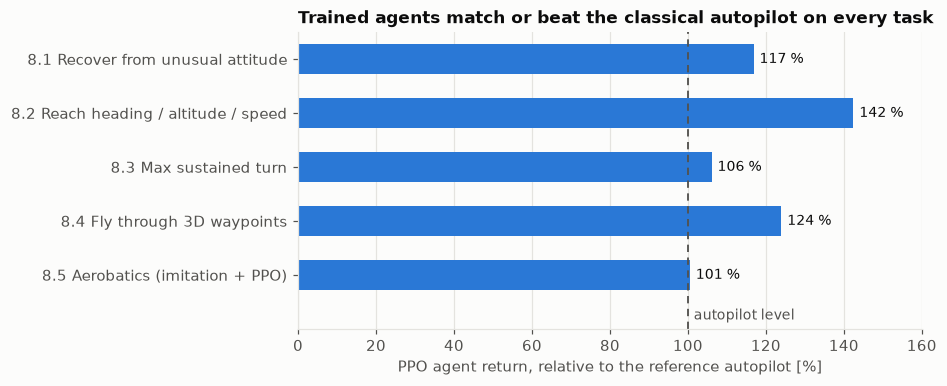

task                                      agent success  autopilot success
8.1 Recover from unusual attitude                 100%               100%
8.2 Reach heading / altitude / speed               90%               100%
8.3 Max sustained turn                            100%               100%
8.4 Fly through 3D waypoints                      100%                90%
8.5 Aerobatics (imitation + PPO)                  100%               100%


In [3]:
results = [
    # task, agent return, reference return, agent success, reference success
    ("8.1 Recover from unusual attitude", 20.8, 17.8, 1.00, 1.00),
    ("8.2 Reach heading / altitude / speed", 126.8, 89.0, 0.90, 1.00),
    ("8.3 Max sustained turn", 290.9, 274.2, 1.00, 1.00),
    ("8.4 Fly through 3D waypoints", 48.6, 39.2, 1.00, 0.90),
    ("8.5 Aerobatics (imitation + PPO)", 58.2, 57.9, 1.00, 1.00),
]
names = [r[0] for r in results][::-1]
ratio = np.array([100 * r[1] / r[2] for r in results])[::-1]

fig, ax = plt.subplots(figsize=(8.5, 3.4), layout="constrained")
bars = ax.barh(names, ratio, color=SERIES[0], height=0.55)
ax.axvline(100, color=INK_2, linewidth=1.2, linestyle=(0, (4, 3)))
ax.text(101.5, -0.75, "autopilot level", color=INK_2, fontsize=9, va="center")
ax.set_ylim(-1.0, len(names) - 0.5)
ax.set_axisbelow(True)
for b, v in zip(bars, ratio, strict=True):
    ax.text(
        v + 1.5, b.get_y() + b.get_height() / 2, f"{v:.0f} %", va="center", color=INK, fontsize=9
    )
ax.set_xlim(0, 160)
ax.set_xlabel("PPO agent return, relative to the reference autopilot [%]")
ax.set_title("Trained agents match or beat the classical autopilot on every task")
ax.grid(axis="y", visible=False)
plt.show()

print(f"{'task':<40}{'agent success':>15}{'autopilot success':>19}")
for name, _, _, s_agent, s_ref in results:
    print(f"{name:<40}{s_agent:>14.0%}{s_ref:>19.0%}")

A few things this chart does **not** show, and which notebook 8 discusses honestly:

* a higher return is not always a better flight : on 8.2 the agent scores higher but fails the
  strict "no overshoot" criterion more often than the autopilot;
* pure RL could not discover the loop, Immelmann and Split-S: the aerobatics agent starts
  from **imitation** of a scripted pilot;
* the harder version : the agent moving the control surfaces directly at 50 Hz, with no
  fly-by-wire to protect it reaches 90–100 % success but 72–100 % of the hierarchical
  agent's return (step 8.6).

## 7. How to run these notebooks

```bash
uv venv && uv pip install -e ".[dev,rl,notebooks]"
uv run jupyter lab notebooks/
```

Notebook 8 trains a small agent live (1–2 minutes) and reads the recorded runs and trained
models stored in `results/runs/`.